In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.base import clone
from functools import partial
from scipy.stats import skew
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier


In [16]:
df = pd.read_csv("Data\\loan_data.csv")

In [17]:
numerical_features = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score"
]
categorical_features = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
]

# Feature Engineering & Selection

In [18]:
# New engineered features

df['loan_burden'] = (df['loan_percent_income'] * df['loan_int_rate'])
df['total_interest_cost'] = df['loan_amnt'] * (df['loan_int_rate'] / 100)
df['income_per_exp_year'] = df['person_income'] / (df['person_emp_exp'] + 1)

new_engineered_features = ['total_interest_cost', 'loan_burden', 'income_per_exp_year']

# sanity check: no NaN / inf introduced
print("NaN:", df[new_engineered_features].isnull().sum().sum())
print("Inf:", np.isinf(df[new_engineered_features]).sum().sum())

df[new_engineered_features].describe().T

NaN: 0
Inf: 0


,count,mean,std,min,25%,50%,75%,max
total_interest_cost,45000.0,1082.261094,856.462705,48.800000,482.400000,829.200,1420.800000,7000.0000
loan_burden,45000.0,1.570424,1.141736,0.000000,0.721000,1.277,2.132050,9.3789
income_per_exp_year,45000.0,27106.454397,30386.826370,258.064516,7561.984375,15463.375,35923.833333,577186.0000


In [19]:
corr = df.corr(numeric_only=True)['loan_status'].sort_values(
    ascending=False
)

print(corr)

loan_status                   1.000000
loan_burden                   0.456610
loan_percent_income           0.384880
loan_int_rate                 0.332005
total_interest_cost           0.209735
loan_amnt                     0.107714
credit_score                 -0.007647
cb_person_cred_hist_length   -0.014851
person_emp_exp               -0.020481
person_age                   -0.021476
income_per_exp_year          -0.102517
person_income                -0.135808
Name: loan_status, dtype: float64


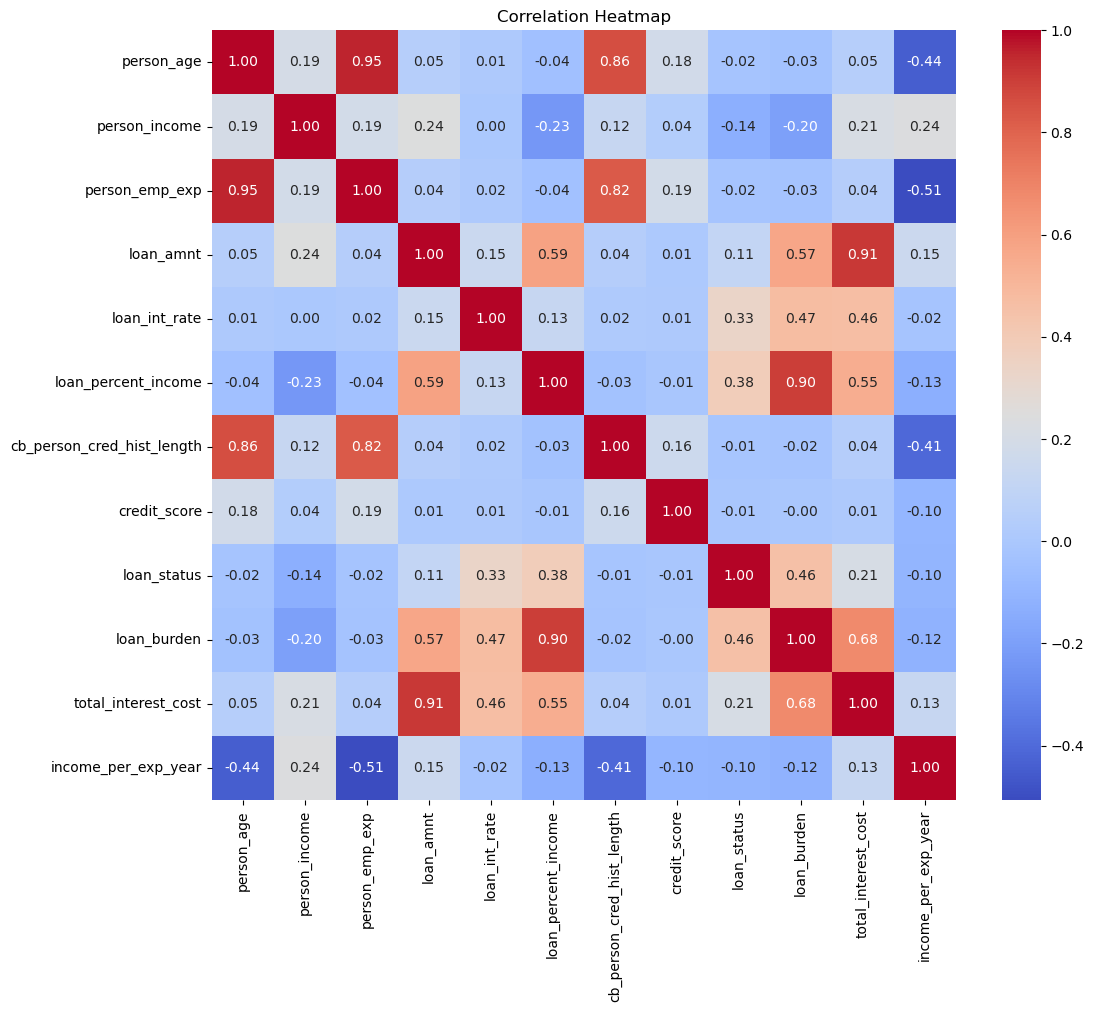

In [20]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

## Feature Selection

### 1. Correlation with target

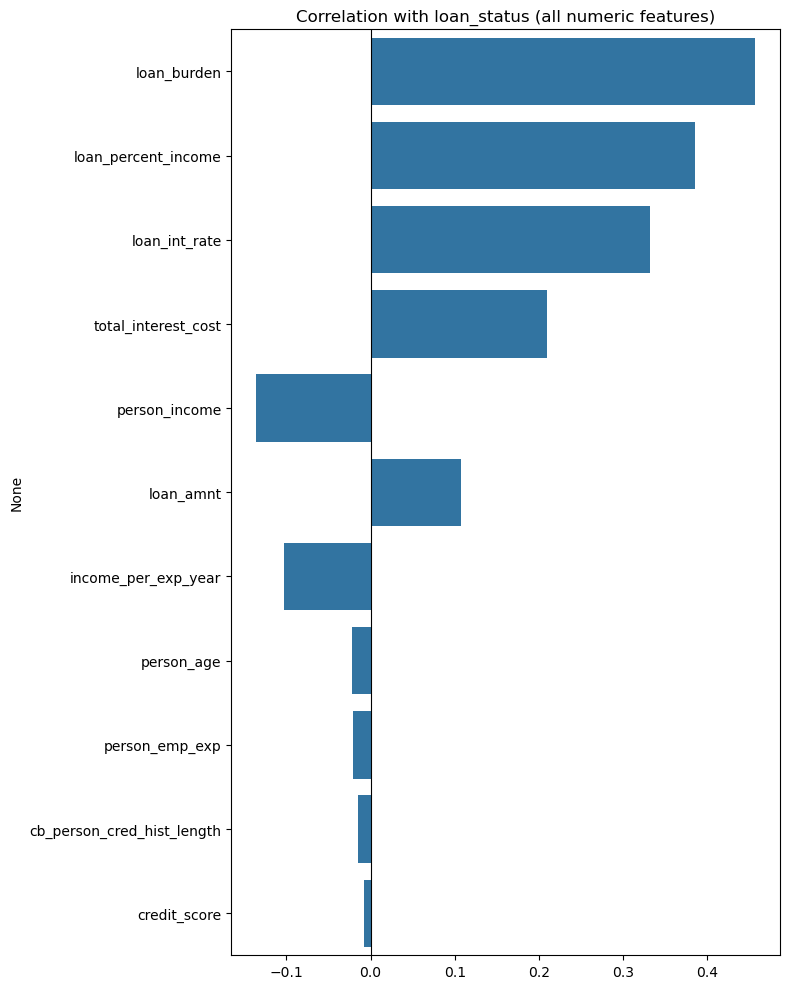

loan_burden                   0.456610
loan_percent_income           0.384880
loan_int_rate                 0.332005
total_interest_cost           0.209735
person_income                -0.135808
loan_amnt                     0.107714
income_per_exp_year          -0.102517
person_age                   -0.021476
person_emp_exp               -0.020481
cb_person_cred_hist_length   -0.014851
credit_score                 -0.007647
Name: loan_status, dtype: float64

In [22]:
corr_with_target = df.corr(numeric_only=True)['loan_status'] \
    .drop('loan_status').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index)
plt.title('Correlation with loan_status (all numeric features)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

corr_with_target

### 2. Multicollinearity check (Pearson + Spearman)

We check both Pearson (linear) and Spearman (rank/monotonic) correlation between the engineered
features and the raw columns they were built from, since a feature can be redundant through a
non-linear relationship (e.g. a ratio vs. its reciprocal) that Pearson alone would miss.

In [23]:
engineered_features = ['loan_burden', 'total_interest_cost', 'income_per_exp_year']

corr_pearson = df[numerical_features + engineered_features].corr(method='pearson').abs()
corr_spearman = df[numerical_features + engineered_features].corr(method='spearman').abs()

upper_p = corr_pearson.where(np.triu(np.ones(corr_pearson.shape), k=1).astype(bool))
upper_s = corr_spearman.where(np.triu(np.ones(corr_spearman.shape), k=1).astype(bool))

print("Highly correlated pairs (Pearson or Spearman > 0.8):\n")
for col in upper_p.columns:
    for row in upper_p.index:
        p, s = upper_p.loc[row, col], upper_s.loc[row, col]
        if pd.notnull(p) and (p > 0.8 or s > 0.8):
            print(f"{row:30s} <-> {col:30s}  Pearson={p:.3f}  Spearman={s:.3f}")

Highly correlated pairs (Pearson or Spearman > 0.8):

person_age                     <-> person_emp_exp                  Pearson=0.954  Spearman=0.888
person_age                     <-> cb_person_cred_hist_length      Pearson=0.862  Spearman=0.821
person_emp_exp                 <-> cb_person_cred_hist_length      Pearson=0.824  Spearman=0.750
loan_percent_income            <-> loan_burden                     Pearson=0.904  Spearman=0.927
loan_amnt                      <-> total_interest_cost             Pearson=0.915  Spearman=0.928
person_emp_exp                 <-> income_per_exp_year             Pearson=0.507  Spearman=0.852


**Finding:**
`loan_burden` is highly correlated with `loan_percent_income` but not to that extreme (~0.9), but it substantially outperforms it in feature importance, so we keep it.

### 3. Random Forest importance & Mutual Information

Categorical columns are one-hot encoded here **only for scoring purposes** (a temporary copy, not saved back to `df`), since these two methods require numeric input.

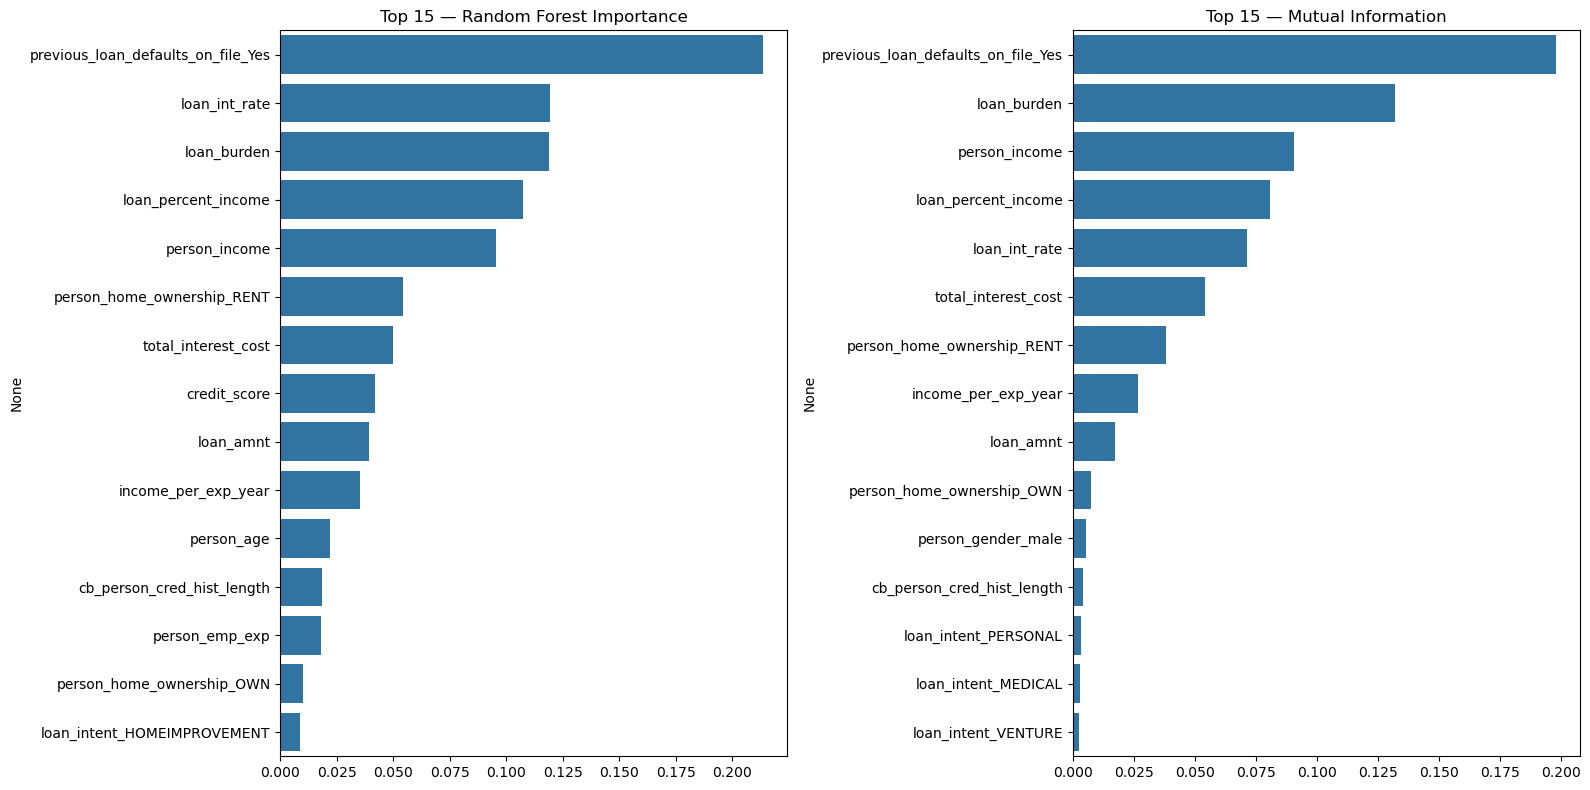

In [24]:
from sklearn.feature_selection import mutual_info_classif

X_scored = pd.get_dummies(df.drop(columns=['loan_status']), columns=categorical_features, drop_first=True)
y_scored = df['loan_status']

rf_score = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_score.fit(X_scored, y_scored)
rf_importance = pd.Series(rf_score.feature_importances_, index=X_scored.columns).sort_values(ascending=False)

mi_scores = mutual_info_classif(X_scored, y_scored, random_state=42)
mi_importance = pd.Series(mi_scores, index=X_scored.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.barplot(x=rf_importance.values[:15], y=rf_importance.index[:15], ax=axes[0])
axes[0].set_title('Top 15 — Random Forest Importance')
sns.barplot(x=mi_importance.values[:15], y=mi_importance.index[:15], ax=axes[1])
axes[1].set_title('Top 15 — Mutual Information')
plt.tight_layout()
plt.show()

Since encoding is deferred to the pipeline (whole categorical columns go in or out, not individual one-hot levels), we also aggregate importance per raw categorical column:

In [25]:
print("Aggregated Random Forest importance per categorical column:\n")
for cat in categorical_features:
    dummy_cols = [c for c in X_scored.columns if c.startswith(cat + "_")]
    print(f"{cat:35s} {rf_importance[dummy_cols].sum():.4f}")

Aggregated Random Forest importance per categorical column:

person_gender                       0.0056
person_education                    0.0142
person_home_ownership               0.0649
loan_intent                         0.0359
previous_loan_defaults_on_file      0.2137


### 4. Final decision

| Feature | Decision | Reason |
|---|---|---|
| `loan_burden` | **Keep** | Strong correlation (0.46) and importance — one of the best predictors overall |
| `total_interest_cost` | **Keep** | Meaningful correlation (0.21) and importance, not redundant with existing columns |
| `income_per_exp_year` | **Keep** | Adds moderate signal beyond raw `person_income` / `person_emp_exp` |
| `person_gender`, `person_education` | Keep, low priority | Weak importance individually but cheap to keep (encoding handles them); flagging for the team in case a simpler model is preferred later |

`loan_burden`, `total_interest_cost`, and `income_per_exp_year` are all right-skewed (skew 1.4–2.7) and become close to symmetric after a log transform, so they're added to `log_cols` below rather than `passthrough_cols`.

In [26]:
selected_numeric_engineered = ['loan_burden', 'total_interest_cost', 'income_per_exp_year']

print("Engineered features going into the pipeline:", selected_numeric_engineered)

Engineered features going into the pipeline: ['loan_burden', 'total_interest_cost', 'income_per_exp_year']


In [27]:
print("df shape now:", df.shape)
df.columns.tolist()

df shape now: (45000, 17)


['person_age',
 'person_gender',
 'person_education',
 'person_income',
 'person_emp_exp',
 'person_home_ownership',
 'loan_amnt',
 'loan_intent',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'credit_score',
 'previous_loan_defaults_on_file',
 'loan_status',
 'loan_burden',
 'total_interest_cost',
 'income_per_exp_year']

In [28]:
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [30]:
X_train.shape, X_test.shape

((36000, 16), (9000, 16))

In [31]:
log_cols = [
    "person_income",
    "loan_amnt",
    "loan_percent_income",
    "cb_person_cred_hist_length",
] + selected_numeric_engineered  # loan_burden, total_interest_cost, income_per_exp_year

passthrough_cols = ["loan_int_rate", "credit_score"]

categorical_cols = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file",
]

linear_preprocessor = ColumnTransformer(transformers=[
    ("age", FunctionTransformer(partial(np.clip, a_min=None, a_max=90)), ["person_age"]),
    ("emp_exp", Pipeline([
        ("cap", FunctionTransformer(partial(np.clip, a_min=None, a_max=60))),
        ("log", FunctionTransformer(np.log1p)),
    ]), ["person_emp_exp"]),
    ("log", FunctionTransformer(np.log1p), log_cols),
    ("scale_pass", StandardScaler(), passthrough_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
])


tree_preprocessor = ColumnTransformer(transformers=[
    ("age", FunctionTransformer(partial(np.clip, a_min=None, a_max=90)), ["person_age"]),
    ("emp_exp", FunctionTransformer(partial(np.clip, a_min=None, a_max=60)), ["person_emp_exp"]),
    ("passthrough_num", "passthrough", log_cols + passthrough_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
])


In [32]:
print("===== Raw Data =====")
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print()

print("===== After Capping =====")
print("Max age after cap:", df["person_age"].clip(upper=90).max(), "(was:", df["person_age"].max(), ")")
print("Max emp_exp after cap:", df["person_emp_exp"].clip(upper=60).max(), "(was:", df["person_emp_exp"].max(), ")")
print()

print("===== Skewness before / after log =====")
for col in log_cols + ["person_emp_exp"]:
    before = skew(df[col])
    after = skew(np.log1p(df[col].clip(upper=60) if col == "person_emp_exp" else df[col]))
    print(f"{col}: {before:.2f} -> {after:.2f}")
print()

print("===== Shape after preprocessing =====")
X_train_lin = linear_preprocessor.fit_transform(X_train)
X_test_lin = linear_preprocessor.transform(X_test)
X_train_tree = tree_preprocessor.fit_transform(X_train)
X_test_tree = tree_preprocessor.transform(X_test)

for name, arr in [
    ("linear train", X_train_lin), ("linear test", X_test_lin),
    ("tree train", X_train_tree), ("tree test", X_test_tree),
]:
    arr = np.asarray(arr)
    print(f"{name}: shape={arr.shape}, NaN count={np.isnan(arr).sum()}")

===== Raw Data =====
Missing values: 0


Duplicates: 0

===== After Capping =====
Max age after cap: 90.0 (was: 144.0 )
Max emp_exp after cap: 60 (was: 125 )

===== Skewness before / after log =====
person_income: 34.14 -> 0.22
loan_amnt: 1.18 -> -0.44
loan_percent_income: 1.03 -> 0.83
cb_person_cred_hist_length: 1.63 -> 0.44
loan_burden: 1.39 -> 0.38
total_interest_cost: 1.76 -> -0.24
income_per_exp_year: 2.65 -> -0.01
person_emp_exp: 2.59 -> -0.13

===== Shape after preprocessing =====
linear train: shape=(36000, 25), NaN count=0
linear test: shape=(9000, 25), NaN count=0
tree train: shape=(36000, 25), NaN count=0
tree test: shape=(9000, 25), NaN count=0


In [33]:
def build_pipeline(model, preprocessor):
    return Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", model),
    ])


model_configs = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=42), linear_preprocessor),
    "KNN": (KNeighborsClassifier(), linear_preprocessor),
    "SVC": (SVC(random_state=42,probability=True) ,linear_preprocessor),
    "Random Forest": (RandomForestClassifier(random_state=42), tree_preprocessor),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42), tree_preprocessor),
    "XGBoost": (XGBClassifier(random_state=42, eval_metric="logloss"), tree_preprocessor),
}

pipelines = {
    name: build_pipeline(model, prep)
    for name, (model, prep) in model_configs.items()
}


In [34]:
pipelines


{'Logistic Regression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('age',
                                                   FunctionTransformer(func=functools.partial(<function clip at 0x0000017F1D728670>, a_min=None, a_max=90)),
                                                   ['person_age']),
                                                  ('emp_exp',
                                                   Pipeline(steps=[('cap',
                                                                    FunctionTransformer(func=functools.partial(<function clip at 0x0000017F1D728670>, a_min=None, a_max=60))),
                                                                   ('log',
                                                                    FunctionTransformer(f...
                                                    'loan_burden',
                                                    'total_interest_cost',
                                      

In [35]:
from sklearn.metrics import accuracy_score, classification_report

pipeline = pipelines['Logistic Regression']

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9043333333333333
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.80      0.76      0.78      2000

    accuracy                           0.90      9000
   macro avg       0.87      0.85      0.86      9000
weighted avg       0.90      0.90      0.90      9000



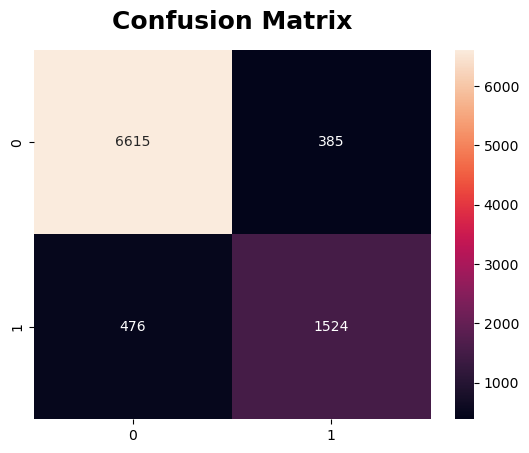

In [36]:
from sklearn.metrics import confusion_matrix
#LOGISTIC RGRESSION
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix", fontsize=18, fontweight="bold", pad=15)
plt.show()

In [37]:
from sklearn.metrics import accuracy_score, classification_report

pipeline = pipelines['KNN']

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8843333333333333
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      7000
           1       0.79      0.65      0.71      2000

    accuracy                           0.88      9000
   macro avg       0.85      0.80      0.82      9000
weighted avg       0.88      0.88      0.88      9000



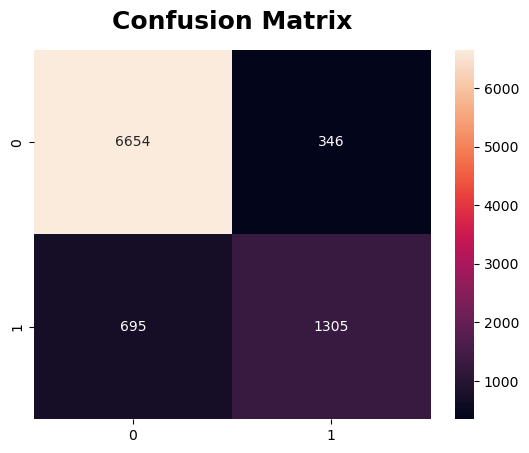

In [38]:
#KNN
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix", fontsize=18, fontweight="bold", pad=15)
plt.show()

In [39]:
pipeline = pipelines['SVC']

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8957777777777778
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      7000
           1       0.80      0.71      0.75      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.83      0.84      9000
weighted avg       0.89      0.90      0.89      9000



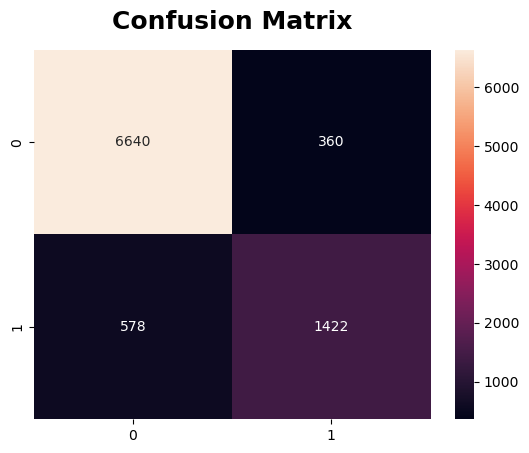

In [40]:
#SVC
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix", fontsize=18, fontweight="bold", pad=15)
plt.show()

In [41]:
pipeline = pipelines['Random Forest']

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9301111111111111
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7000
           1       0.90      0.77      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



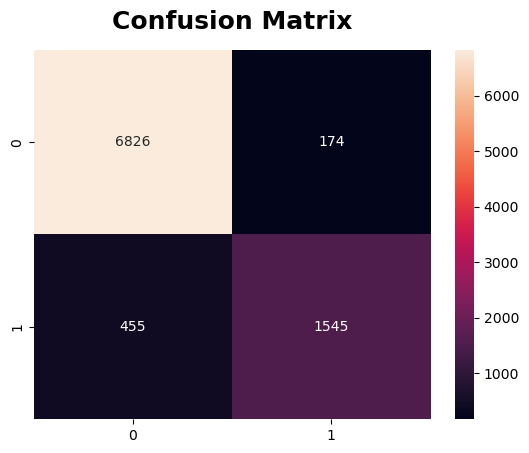

In [42]:
#RANDOM FOREST
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix", fontsize=18, fontweight="bold", pad=15)
plt.show()

In [43]:
pipeline = pipelines['Gradient Boosting']

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9224444444444444
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7000
           1       0.87      0.76      0.81      2000

    accuracy                           0.92      9000
   macro avg       0.90      0.87      0.88      9000
weighted avg       0.92      0.92      0.92      9000



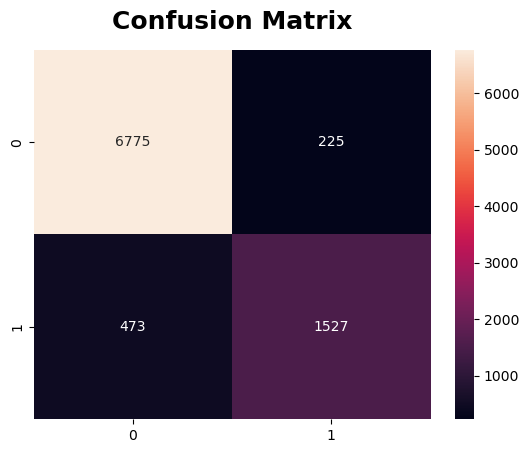

In [44]:
#GRADIENT BOOSTING
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix", fontsize=18, fontweight="bold", pad=15)
plt.show()

In [45]:
pipeline = pipelines['XGBoost']

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9356666666666666
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7000
           1       0.89      0.82      0.85      2000

    accuracy                           0.94      9000
   macro avg       0.92      0.89      0.90      9000
weighted avg       0.93      0.94      0.93      9000



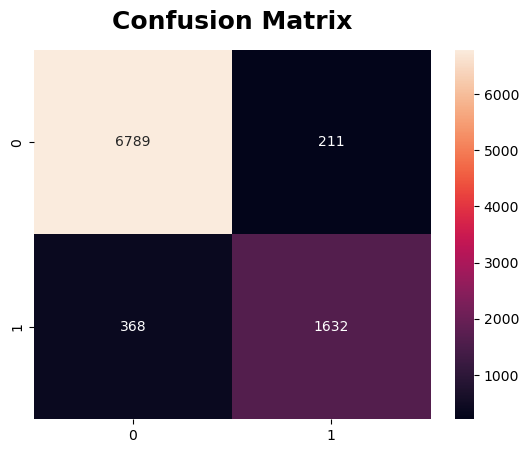

In [46]:
#XGBOOST
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix", fontsize=18, fontweight="bold", pad=15)
plt.show()

In [47]:
results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    score = pipe.score(X_test, y_test)
    results[name] = score
    print(f"{name} Test Accuracy: {score:.4f}")

Logistic Regression Test Accuracy: 0.9043
KNN Test Accuracy: 0.8843
SVC Test Accuracy: 0.8958
Random Forest Test Accuracy: 0.9301
Gradient Boosting Test Accuracy: 0.9224
XGBoost Test Accuracy: 0.9357


In [48]:
from sklearn.metrics import roc_auc_score, f1_score

comparison = []
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    comparison.append({
        'Model': name,
        'AUC': roc_auc_score(y_test, y_proba),
        'F1': f1_score(y_test, y_pred)
    })

pd.DataFrame(comparison).sort_values('AUC', ascending=False)

,Model,AUC,F1
5,XGBoost,0.978358,0.849336
3,Random Forest,0.974727,0.830869
4,Gradient Boosting,0.971823,0.813966
0,Logistic Regression,0.958600,0.779739
2,SVC,0.943494,0.751983
1,KNN,0.905698,0.714873


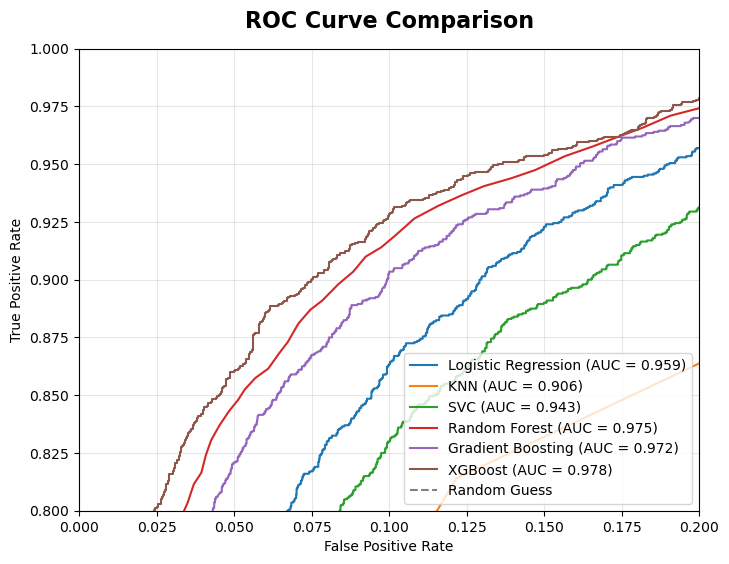

In [49]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, pipe in pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')


plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontsize=16, fontweight='bold', pad=15)
plt.legend(loc='lower right')
plt.xlim(0, 0.2)
plt.ylim(0.8, 1.0)
plt.grid(alpha=0.3)
plt.show()